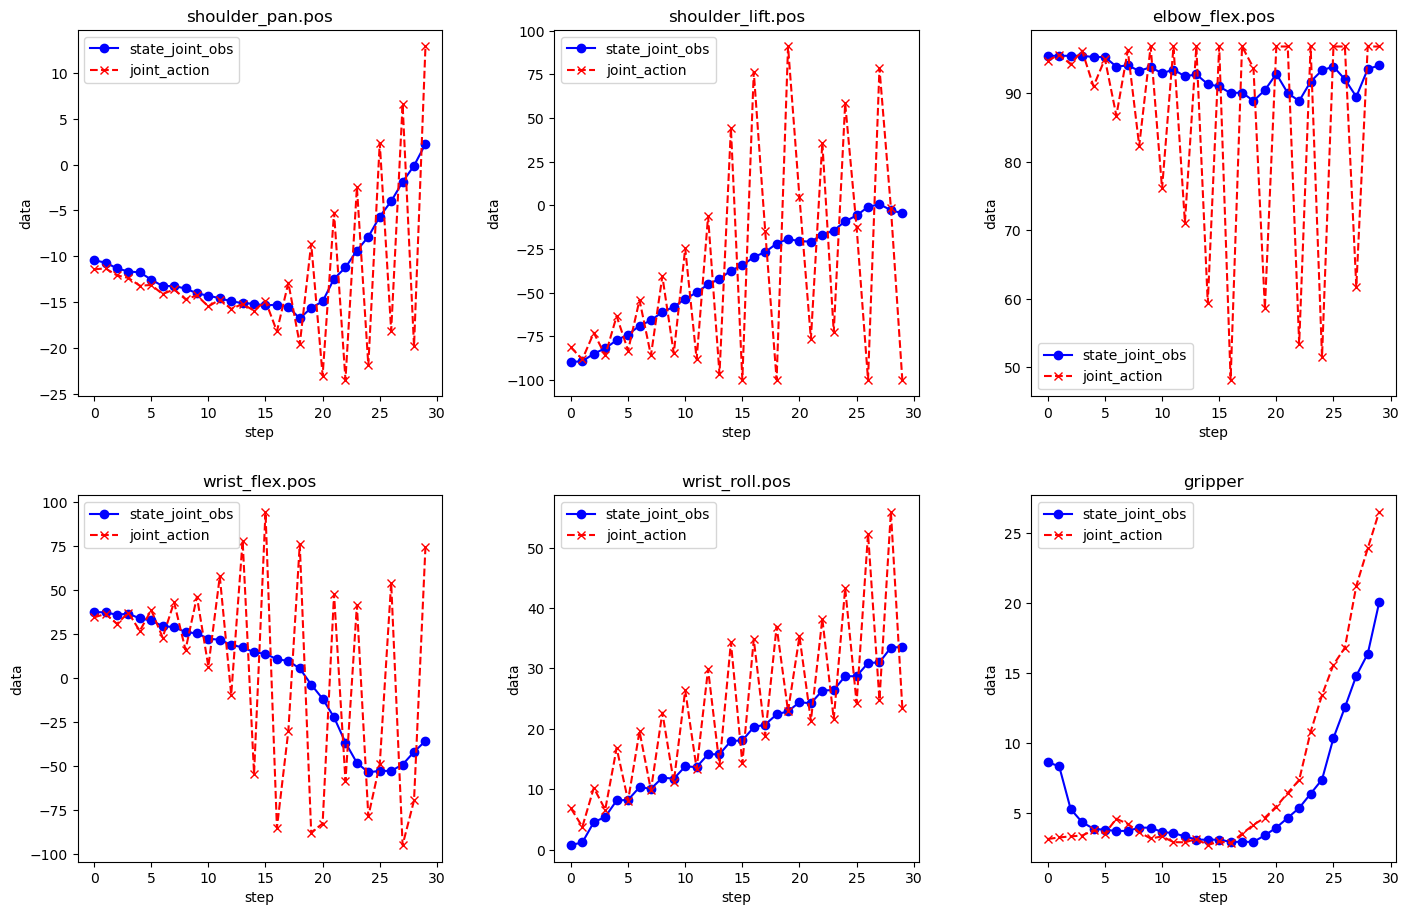

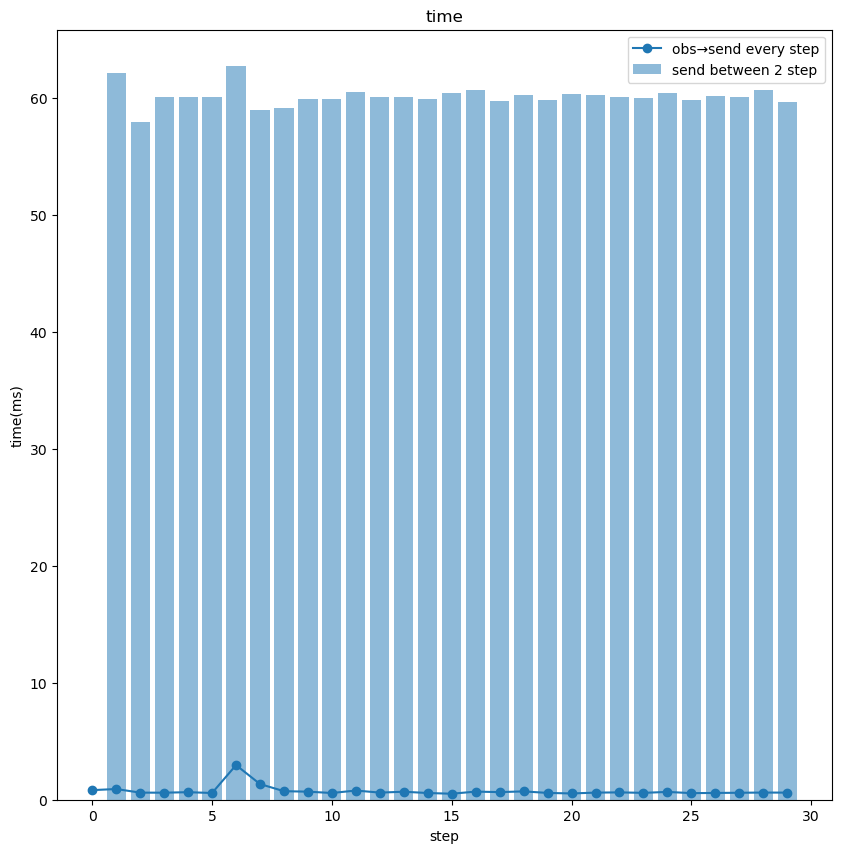

In [33]:
import re
import matplotlib.pyplot as plt
import numpy as np

# 读取文件
filename = 'server.txt'

# 定义正则表达式模式，用于提取需要的数据
state_joint_obs_pattern = re.compile(r"state_joint_obs:([^\{]+)\{([^\}]+)\}")

joint_action_pattern = re.compile(r"joint_action=\{([^\}]+)\}")

# 提取出需要的数据
state_joint_obs_data = []
joint_action_data = []
steps = []
obs_time_data = []   # 获取obs的时间
send_time_data = []  # 发送之后的时间


with open(filename, 'r', encoding='utf-8') as f:
    lines = f.readlines()
    for i in range(0, len(lines), 3):  # 每三个行表示一个数据点
        # 第1行是获取obs的时间, 我们跳过
        # 第2行包含state_joint_obs和joint_action
        line2 = lines[i + 1].strip()

        # 提取state_joint_obs的内容
        state_joint_obs_match = state_joint_obs_pattern.search(line2)
        if state_joint_obs_match:
            state_joint_obs_str = state_joint_obs_match.group(1)
            state_joint_obs = dict(re.findall(r"([\w\.]+)\s*=\s*([\-0-9\.]+)", state_joint_obs_str))
        
        # 提取joint_action的内容
        joint_action_match = joint_action_pattern.search(line2)
        if joint_action_match:
            joint_action_str = joint_action_match.group(1)
            joint_action_str = joint_action_str.replace("\'", "")  # 去掉单引号

            joint_action = dict(re.findall(r"([\w\.]+)\s*:\s*([\-0-9\.]+)", joint_action_str))
        
        # 只取6个关键字的数值
        keys = ['shoulder_pan.pos', 'shoulder_lift.pos', 'elbow_flex.pos', 
                'wrist_flex.pos', 'wrist_roll.pos', 'gripper']
        
        # 记录这些数值
        state_vals = [float(state_joint_obs[key]) for key in keys]
        joint_vals = [float(joint_action[key]) for key in keys]
        obs_time = float(lines[i].strip().split(':')[1])         # 第1行获取obs的时间
        send_time = float(lines[i+2].strip().split(':')[1])     # 第3行发送之后的时间
        obs_time_data.append(obs_time)
        send_time_data.append(send_time)

        # 保存数据
        state_joint_obs_data.append(state_vals)
        joint_action_data.append(joint_vals)
        steps.append(i // 3)  # 步骤编号

# 转换为numpy数组便于操作
state_joint_obs_data = np.array(state_joint_obs_data)
joint_action_data = np.array(joint_action_data)
step_time_diff = [(send - obs)*1000 for obs, send in zip(obs_time_data, send_time_data)]
send_interval = [(send_time_data[i] - send_time_data[i-1])*1000 for i in range(1, len(send_time_data))]


# 绘制图表
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.tight_layout(pad=5.0)

for i, key in enumerate(keys):
    ax = axs[i // 3, i % 3]
    ax.plot(steps, state_joint_obs_data[:, i], label='state_joint_obs', color='b', linestyle='-', marker='o')
    ax.plot(steps, joint_action_data[:, i], label='joint_action', color='r', linestyle='--', marker='x')
    ax.set_title(key)
    ax.set_xlabel('step')
    ax.set_ylabel('data')
    ax.legend()

plt.show()

plt.figure(figsize=(10,10))
plt.plot(range(len(step_time_diff)), step_time_diff, marker='o', label='obs→send every step')
plt.bar(range(1, len(send_interval)+1), send_interval, alpha=0.5, label='send between 2 step')
plt.xlabel('step')
plt.ylabel('time(ms)')
plt.title('time')
plt.legend()
plt.show()



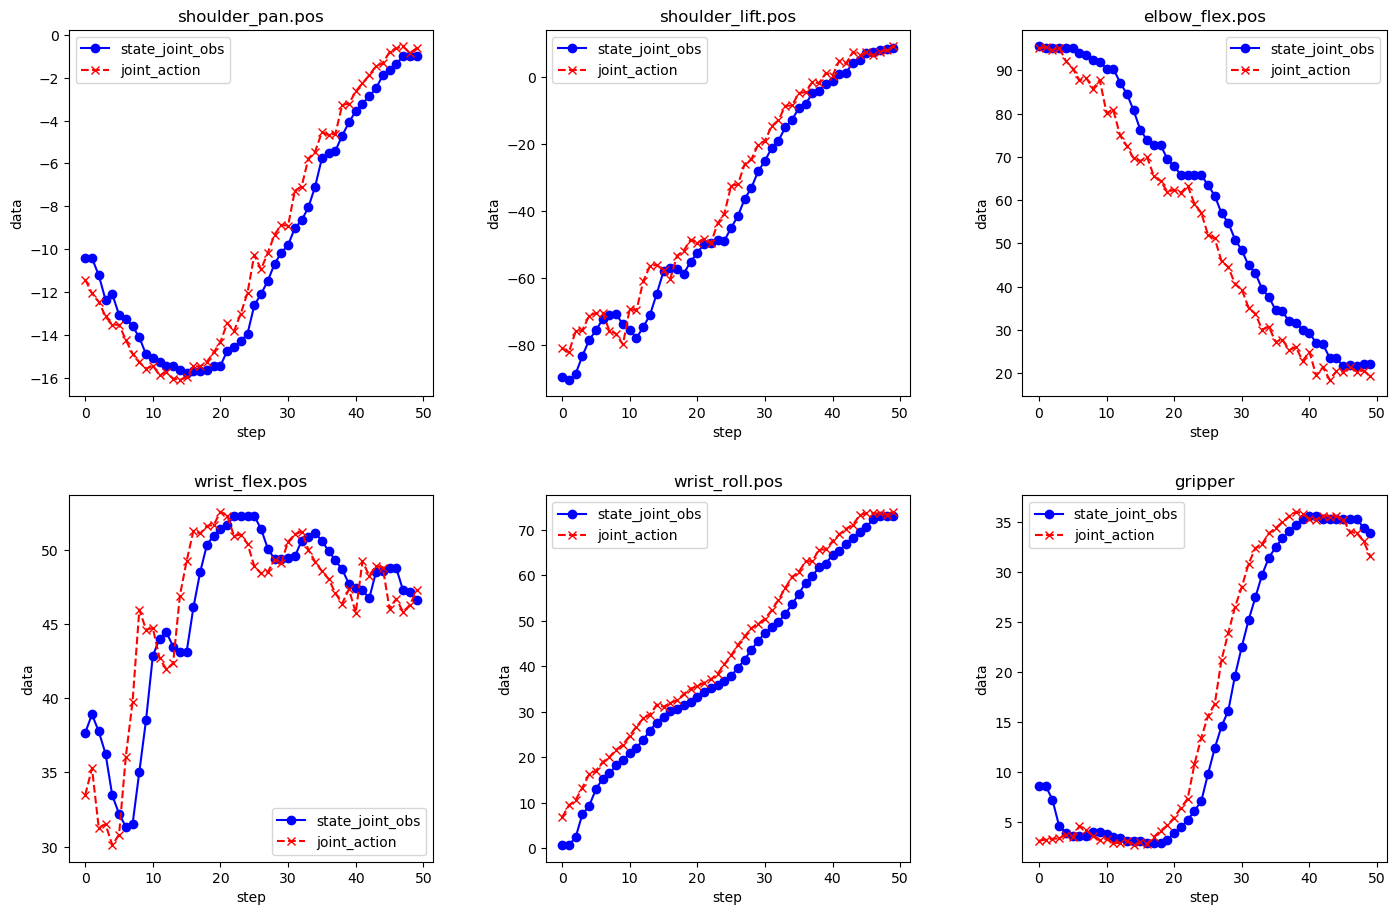

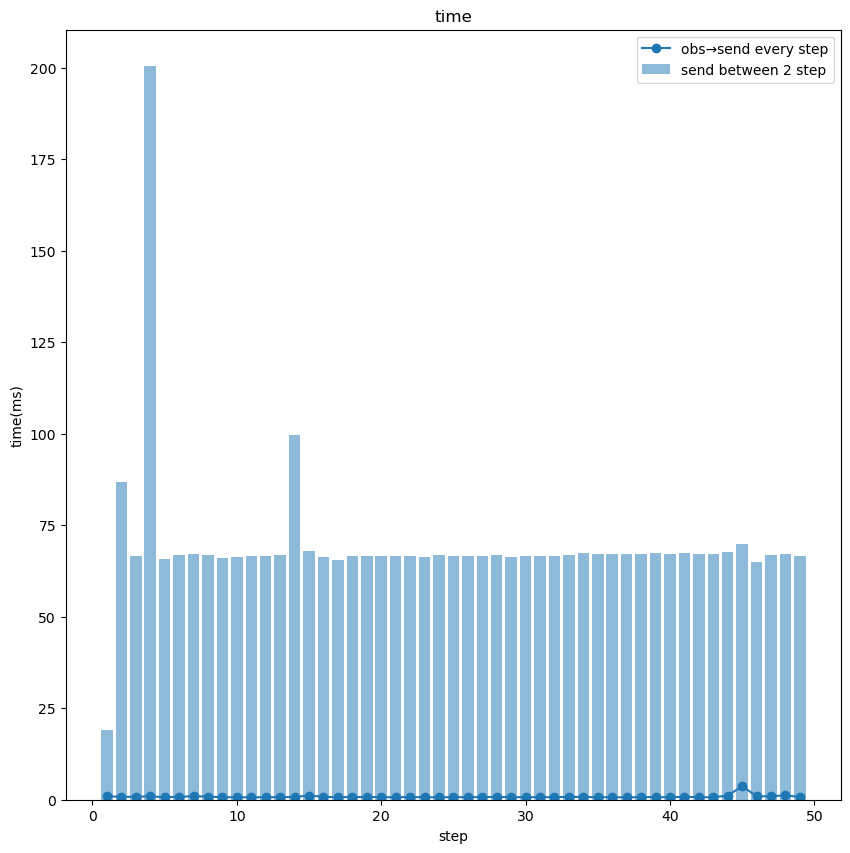

In [41]:
import re
import matplotlib.pyplot as plt
import numpy as np

# 读取文件
filename = 'local.txt'

# 定义正则表达式模式，用于提取需要的数据
state_joint_obs_pattern = re.compile(r"state_joint_obs:([^\{]+)\{([^\}]+)\}")

joint_action_pattern = re.compile(r"joint_action=\{([^\}]+)\}")

# 提取出需要的数据
state_joint_obs_data = []
joint_action_data = []
steps = []
obs_time_data = []   # 获取obs的时间
send_time_data = []  # 发送之后的时间


with open(filename, 'r', encoding='utf-8') as f:
    lines = f.readlines()
    for i in range(0, len(lines), 3):  # 每三个行表示一个数据点
        # 第1行是获取obs的时间, 我们跳过
        # 第2行包含state_joint_obs和joint_action
        line2 = lines[i + 1].strip()

        # 提取state_joint_obs的内容
        state_joint_obs_match = state_joint_obs_pattern.search(line2)
        if state_joint_obs_match:
            state_joint_obs_str = state_joint_obs_match.group(1)
            state_joint_obs = dict(re.findall(r"([\w\.]+)\s*=\s*([\-0-9\.]+)", state_joint_obs_str))
        
        # 提取joint_action的内容
        joint_action_match = joint_action_pattern.search(line2)
        if joint_action_match:
            joint_action_str = joint_action_match.group(1)
            joint_action_str = joint_action_str.replace("\'", "")  # 去掉单引号

            joint_action = dict(re.findall(r"([\w\.]+)\s*:\s*([\-0-9\.]+)", joint_action_str))
        
        # 只取6个关键字的数值
        keys = ['shoulder_pan.pos', 'shoulder_lift.pos', 'elbow_flex.pos', 
                'wrist_flex.pos', 'wrist_roll.pos', 'gripper']
        
        # 记录这些数值
        state_vals = [float(state_joint_obs[key]) for key in keys]
        joint_vals = [float(joint_action[key]) for key in keys]
        obs_time = float(lines[i].strip().split(':')[1])         # 第1行获取obs的时间
        send_time = float(lines[i+2].strip().split(':')[1])     # 第3行发送之后的时间
        obs_time_data.append(obs_time)
        send_time_data.append(send_time)

        # 保存数据
        state_joint_obs_data.append(state_vals)
        joint_action_data.append(joint_vals)
        steps.append(i // 3)  # 步骤编号

# 转换为numpy数组便于操作
state_joint_obs_data = np.array(state_joint_obs_data)
joint_action_data = np.array(joint_action_data)
step_time_diff = [(send - obs)*1000 for obs, send in zip(obs_time_data, send_time_data)]
send_interval = [(send_time_data[i] - send_time_data[i-1])*1000 for i in range(1, len(send_time_data))]


# 绘制图表
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.tight_layout(pad=5.0)

for i, key in enumerate(keys):
    ax = axs[i // 3, i % 3]
    ax.plot(steps, state_joint_obs_data[:, i], label='state_joint_obs', color='b', linestyle='-', marker='o')
    ax.plot(steps, joint_action_data[:, i], label='joint_action', color='r', linestyle='--', marker='x')
    ax.set_title(key)
    ax.set_xlabel('step')
    ax.set_ylabel('data')
    ax.legend()

plt.show()

plt.figure(figsize=(10,10))
plt.plot(range(1, len(step_time_diff)), step_time_diff[1:], 
         marker='o', label='obs→send every step')

plt.bar(range(1, len(send_interval)+1), send_interval, alpha=0.5, label='send between 2 step')
plt.xlabel('step')
plt.ylabel('time(ms)')
plt.title('time')
plt.legend()
plt.show()

